<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/OMDS_ModB2_Week5_Turay_Abdul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5: Bivariate Analysis

**Student Name:** Abdul Karim Turay  
**Course:** DX699S O2 AI for Leaders / OMSDS  
**Instructor:** Dr. Joshua Von Korff

## 1. Introduction

This assignment looks at bivariate analysis utilizing the Diabetes 130-US Hospitals dataset. Bivariate analysis looks at the relationship between two variables and helps uncover patterns, trends, and potential relationships in the data. These relationships are investigated using various visualization approaches, such as scatter plots, count plots, boxplots, and correlation matrices. The goal is to learn more about factors influencing hospital stays, medication use, and patient readmission outcomes while demonstrating the application of graphical and statistical data analysis methodologies.


In [26]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

## 2. Lesson: Bivariate Graphs
In this lesson, we will review bivariate plots, including scatter plots, pair plots, correlation tables, waterfall plots, line plots, and area plots.

In [27]:
np.random.seed(0)
numpoints = 100

lesson_series_uniform = np.round(np.random.random(size=numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size=numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale=10, size=numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale=10, size=numpoints)

<Axes: >

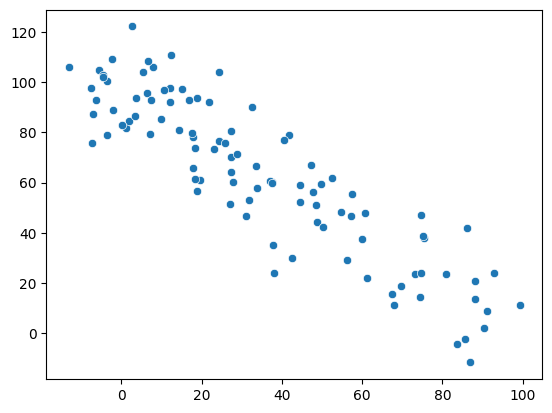

In [28]:
sns.scatterplot(x=lesson_series_skewed, y=lesson_series_reverse)

### Analysis

The scatter plot compares the skewed and reverse datasets. The points form a clear downward trend, indicating that as values in the skewed dataset increase, values in the reverse dataset tend to decrease. This demonstrates a strong negative relationship between the two variables.

### Conclusions

- The two variables are negatively correlated.
- Higher values in the skewed dataset are associated with lower values in the reverse dataset.
- The scatter plot provides visual evidence of an inverse relationship.
- The relationship appears approximately linear.

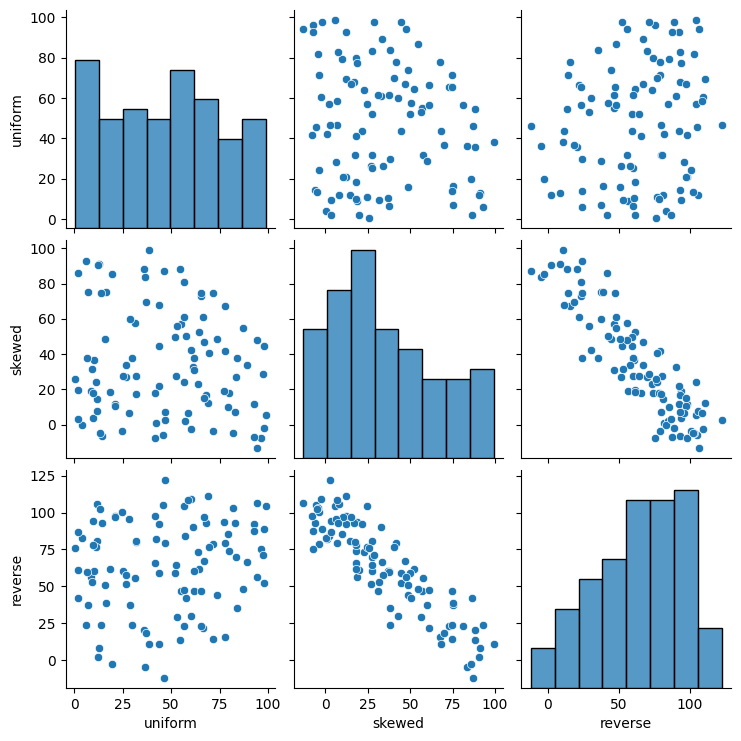

In [29]:
df = pd.DataFrame(
    np.array([
        lesson_series_uniform,
        lesson_series_skewed,
        lesson_series_reverse
    ]).T,
    columns=['uniform', 'skewed', 'reverse']
)

sns.pairplot(df)

### Analysis

The pair plot depicts the associations between the uniform, skewed, and reverse datasets. The diagonal plots show the distribution of each variable, whereas the off-diagonal plots offer scatter plots of pairs of variables. The uniform dataset has little correlation with the other two variables, as seen by the random cloud patterns. In contrast, the skewed and reverse datasets show a strong negative correlation, resulting in a distinct downward trend.

### Conclusions

- The uniform dataset is largely unassociated with the other variables.
- The skewed and reverse datasets have a substantial negative correlation.
- The diagonal histograms allow visualization of each variable's distribution.
- Pair plots are an effective technique for analyzing numerous relationships at once.

In [30]:
print("Correlations:")
print(df.corr())

Correlations:
          uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


### Analysis

The correlation table quantifies the relationship between the three datasets. The correlation between the skewed and reverse datasets is -0.895, showing a strong negative relationship. The uniform dataset displays weak correlations with both the skewed (-0.145) and reverse (0.150) datasets, indicating little or no meaningful association. These findings support the trends identified in the scatter plot and pair plot.

### Conclusions

- The skewed and reverse datasets show the strongest correlation (r = -0.895).
- The skewed and reverse datasets have a substantial negative correlation.
- The uniform dataset shows only weak associations with the other variables.
- The numerical results confirm the visual patterns observed in the graphs.

### 2.3.1 What do correlations tell us?

A correlation indicates the intensity and direction of a relationship between two variables. A positive correlation suggests that the variables tend to rise or decrease together, whereas a negative correlation indicates that one variable increases while the other drops. A correlation around zero indicates a lack of a linear relationship between variables.

### 2.3.2 How do you determine whether a correlation is strong?

The strength of a correlation varies according to the situation and field of inquiry. Correlations greater than 0.7 or less than -0.7 are generally considered strong, whereas correlations near zero are regarded as weak. In some domains, such as the social sciences, correlations as low as 0.2 may be considered significant.

### 2.3.3 What is the goal of discovering a correlation?

Correlation analysis identifies relationships between variables and determines whether they are useful predictors. It can also identify redundant variables that provide similar information, indicate potential data issues, and provide important insights when presenting a dataset.

### Conclusions

- The skewed and reverse datasets have a substantial negative association (r = -0.895).
- The uniform dataset exhibits only weak correlations with the other variables.
- Correlation values reflect the strength and direction of relationships.
- Correlation analysis can help with prediction, feature selection, and data quality assessment.
- The numerical results confirm the patterns shown in the scatter and pair plots.

### 2.4 Waterfall Plot

In [31]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])

### Analysis

The waterfall plot shows how a value changes as a result of positive and negative contributions. The chart starts with an initial total, then increases through receipts and interest income, and finally decreases through expenses and interest payments. Green bars represent positive contributions, while red bars represent negative contributions. The final value reflects the total impact of all additions and subtractions. This type of visualization is useful for determining how different components contribute to an overall change.

### Conclusions

- The waterfall plot depicts the cumulative effects of successive increases and decreases.
- Receipts and interest income contribute to the overall total.
- Expenses and interest payments reduce the overall total.
- The final value is the net effect of all adjustments applied.
- Waterfall plots are useful for visualizing how separate components affect the overall outcome.

### 2.5 Line Plot

/tmp/ipykernel_1902/2082488306.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



<Axes: xlabel='None'>

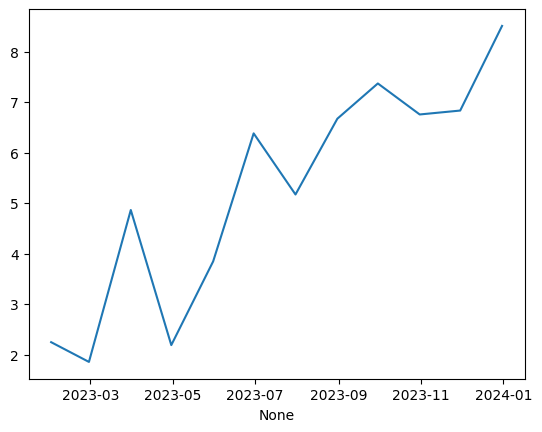

In [32]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
sns.lineplot(x = datearray, y = time_series)

### 2.5 Line Plot Analysis

The line plot shows how a variable evolves over time, from January 2023 to January 2024. Despite occasional short-term variations, the general pattern indicates an upward trend. The values climb gradually over the year, with a few brief dips before continuing to rise. Line plots are excellent for identifying trends, seasonal patterns, and variations over a set of dates.

### Conclusions

- The variable has generally increased over the observed time period.
- A few short-term swings occur, but the overall trend is positive.
- The highest values occur toward the end of the time series.
- Line charts are helpful for displaying changes and trends over time.
- Time-based visualizations assist in identifying patterns that may not be visible from summary statistics alone.

### 2.6 Area Plot

<Axes: >

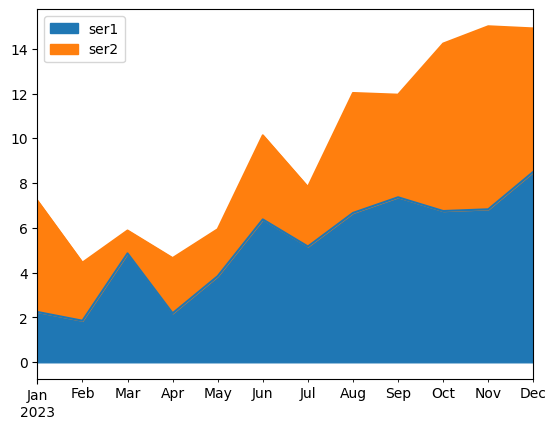

In [33]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

### 2.6 Area Plot Analysis
The area plot depicts two time series (ser1 and ser2) over a certain time period. The shaded regions depict both the individual values and the total of the two series. Both factors normally grow over the year, with minor swings. The stacking style allows you to quickly observe how each series contributes to the overall total and how the combined number varies over time.### Conclusions:- Both ser1 and ser2 levels have generally increased during the observation period.- Short-term volatility exist, but the main tendency is upward.- The stacked regions represent the contribution of each series to the total value.- The combined total reaches its peak around the conclusion of the year.- Area plots are useful for showing cumulative trends and comparing numerous time series at once.

## 3. Weekly Graph Question


In [34]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

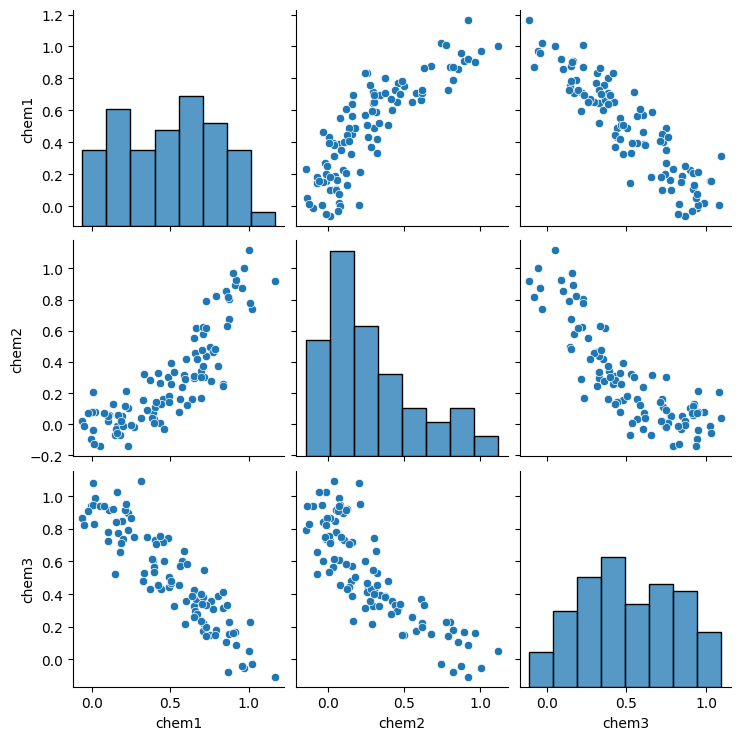

In [35]:
sns.pairplot(df_chem)

### 3.1 Which three graphs do you prefer?

I would select the scatter plots that compare chem1 vs chem2, chem1 vs chem3, and chem2 vs chem3. These three graphs are the most relevant since they show the correlations between the three substances. The scatter plots indicate correlations between variables, while the diagonal histograms depict distributions.

### 3.2 How would you make the graphs more clear and informative?

I would provide descriptive titles, axis labels, and trend lines. Increasing the figure size and using different colors or transparency for the points would improve readability. Putting correlation values on the graphs would also assist in quantifying the links between the variables.

### 3.3 Would any of these graphs fit a line or curve? Why or why not?

Yes. I would fit a straight line to the relationship between chem1 and chem3 because the scatter plot shows a strong negative linear trend. I would use curves to plot chem1 vs chem2 and chem2 vs chem3 because the relationships appear nonlinear, with the points following a curved pattern rather than a straight line.

### 3.4 If you had to choose only one graph, which would it be?

I would prefer the scatter plot of chem1 versus chem3 because it demonstrates the most obvious relationship. The significant negative linear trend facilitates interpretation and explanation of the relationship.

### 3.5 Which graph would you pick if you had to select six?

I would select all six off-diagonal scatter plots from the pair plot. Although some graphs are mirror images of one another, they provide a comprehensive understanding of the pairwise relationships between chem1, chem2, and chem3.

## Conclusions

* The strongest linear association is found between chem1 and chem3.
* Chem1 and chem2 have a positive nonlinear relationship.
* Chem2 and chem3 have a negative nonlinear relationship.
* When examining relationships between variables, scatter plots are more informative than histograms.
* Trend lines and curves can be useful for summarizing patterns and improving interpretation.


## 4. Homework: Reproducing Pair Plot Graphs

###4.1 Reproducing a Normal Scatter Plot

<Axes: xlabel='data1', ylabel='data2'>

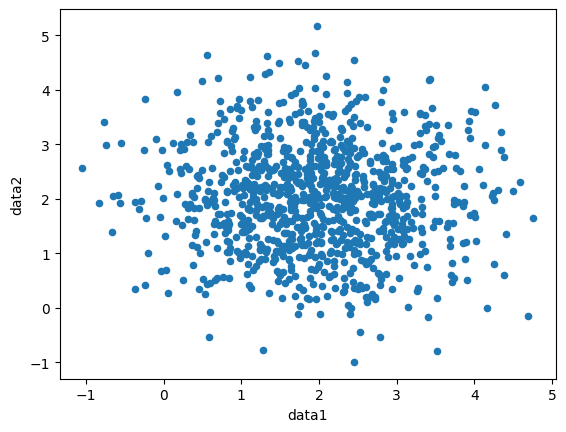

In [36]:
num_points = 1000
np.random.seed(0)

data1 = np.random.normal(size=num_points) + 2
data2 = np.random.normal(size=num_points) + 2

df_twonorm = pd.DataFrame({"data1": data1, "data2": data2})
df_twonorm.plot.scatter(x="data1", y="data2")


### Analysis

The scatter plot shows a cloud of points centered at around (2, 2). The points are randomly distributed in both directions, with no discernible upward or descending tendency. This pattern indicates that the two variables were generated independently from normal distributions, with little or no correlation. The graph looks like a conventional bivariate normal cloud.

### Conclusions

- The scatter plot represents a single random cloud of points.
- There is no clear positive or negative correlation.
- The factors seem to be independent.
- The distribution is nearly centered at (2, 2).
- Scatter plots can be used to determine the relationships between variables.

###4.2 Reproducing Three Clouds Scatter Plot

<Axes: xlabel='data_A', ylabel='data_B'>

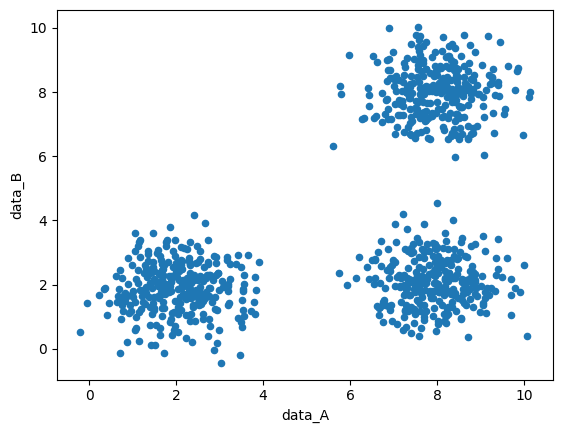

In [37]:
num_points = 900
np.random.seed(0)

x1 = np.random.normal(2, 0.8, 300)
y1 = np.random.normal(2, 0.8, 300)

x2 = np.random.normal(8, 0.8, 300)
y2 = np.random.normal(2, 0.8, 300)

x3 = np.random.normal(8, 0.8, 300)
y3 = np.random.normal(8, 0.8, 300)

x = np.concatenate([x1, x2, x3])
y = np.concatenate([y1, y2, y3])

df_three = pd.DataFrame({
    "data_A": x,
    "data_B": y
})

df_three.plot.scatter(x="data_A", y="data_B")

### Analysis

The scatter plot shows three separate point groups. One cluster appears in the lower left, another in the lower right, and a third in the top right region. The fragmentation of the clusters suggests that the data were derived from various distributions rather than a single population. The clusters form an organized pattern that is not obvious in summary statistics.

### Conclusions

- The scatter plot shows three distinct clusters.
- The clusters show that there are numerous underlying populations.
- The lower-left and lower-right groups have comparable vertical placements.
- The upper-right group is distinguished from the others along both axes.
- Scatter plots are useful for finding hidden group structures in data.

##4.3 Reproducing the Histogram

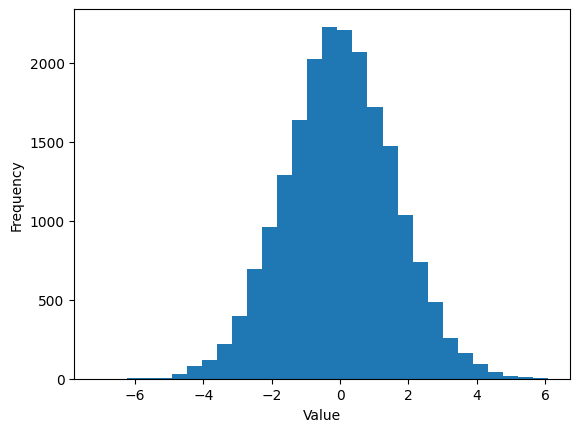

In [38]:
import numpy as np
import matplotlib.pyplot as plt

num_points = 20000
np.random.seed(0)

arr = np.random.normal(loc=0, scale=1.6, size=num_points)

plt.hist(arr, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### Analysis

The histogram showed a relatively symmetric, bell-shaped distribution centered on zero. The frequencies were highest near the middle of the distribution, and they steadily decreased toward both tails. The form was typical of a normal distribution, with observations becoming less frequent as one proceeded away from the center.

### Conclusions

- The histogram had a roughly normal distribution.
- The majority of observations happened at the center of the distribution.
- Frequencies steadily reduced towards both tails.
- The distribution was symmetrical around zero.
- Histograms were beneficial for determining the shape, dispersion, and center of a dataset.

## 4.4 U-Shaped Line Plot

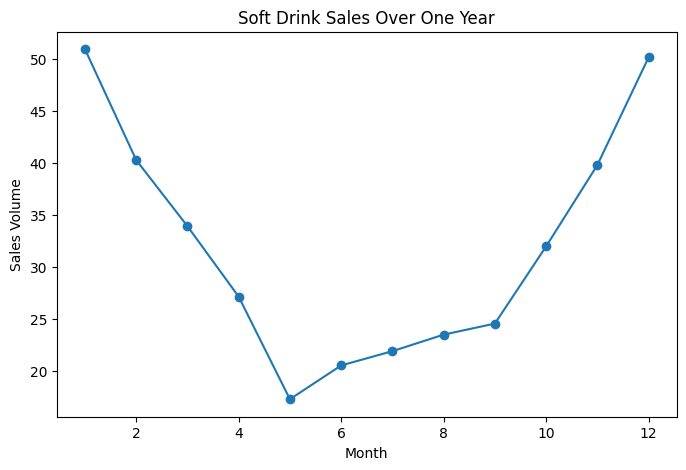

In [39]:
months = np.arange(1, 13)

sales = (months - 6.5)**2 + np.random.normal(0, 2, len(months)) + 20

plt.figure(figsize=(8,5))
plt.plot(months, sales, marker='o')
plt.xlabel("Month")
plt.ylabel("Sales Volume")
plt.title("Soft Drink Sales Over One Year")
plt.show()

### Analysis.
The line plot revealed a U-shaped pattern over the course of a year. Sales volumes fell throughout the first half of the year, reached a low in the middle months, and then increased in the second half. Small random variations were found, indicating noise in the data. Despite this heterogeneity, the overall U-shaped pattern was obvious.

### Conclusions

- Sales decreased during the first half of the year.
- Sales increased during the second half of the year.
- The overall pattern formed a U-shaped curve.
- Random noise introduced realistic variation into the data.
- Line plots were useful for examining trends over time.

# 4.5 Area Plot

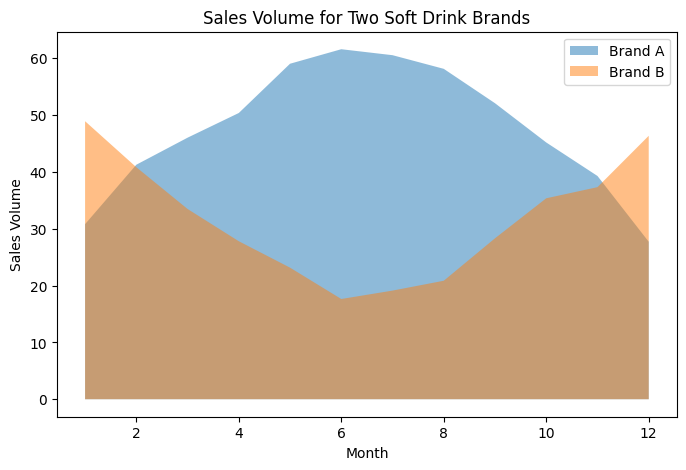

In [40]:
months = np.arange(1, 13)

brand_A = -(months - 6.5)**2 + 60 + np.random.normal(0, 2, len(months))
brand_B = (months - 6.5)**2 + 20 + np.random.normal(0, 2, len(months))

plt.figure(figsize=(8,5))

plt.fill_between(months, brand_A, alpha=0.5, label="Brand A")
plt.fill_between(months, brand_B, alpha=0.5, label="Brand B")

plt.xlabel("Month")
plt.ylabel("Sales Volume")
plt.title("Sales Volume for Two Soft Drink Brands")
plt.legend()

plt.show()
plt.close()

### Analysis

The area plot demonstrated differing sales patterns for two soft drink brands over the course of the year. Brand A climbed in the first half of the year, peaked in the middle months, and then declined. Brand B had the reverse tendency, initially declining before increasing later in the year. Small changes occurred owing to random variation, but the overall trends remained obvious.

### Conclusions

- Brand A's sales volume increased before decreasing.
- Brand B saw a decrease followed by an increase in sales volume.
- The two brands have contrasting sales patterns.
- Random noise provided genuine variance to the trends.
- Area plots were useful for comparing changes in several series across time.

## 4.6 Recreated Pair Plot Visualization

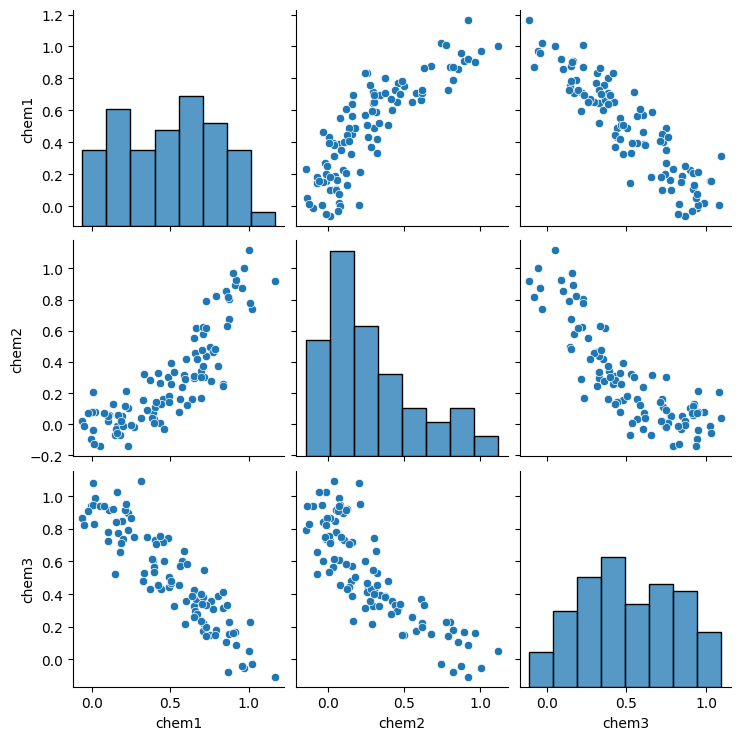

In [41]:
np.random.seed(0)

num_data = 100
base_data = np.random.random(size=num_data)

chem1 = base_data + np.random.normal(size=num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size=num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size=num_data) * 0.1

df_chem = pd.DataFrame({
    "chem1": chem1,
    "chem2": chem2,
    "chem3": chem3
})

sns.pairplot(df_chem)
plt.show()
plt.close()

### Analysis

The pair plot depicts the interactions among chem1, chem2, and chem3. The diagonal histograms depict the distributions of each variable, whereas scatter plots illustrate pairwise correlations. Chem1 and chem2 have a positive nonlinear correlation, while chem1 and chem3 have a significant negative linear relationship. Chem2 and chem3 similarly exhibit a negative nonlinear connection. The use of histograms and scatter plots allows for the simultaneous evaluation of distributions and relationships.

### Conclusions

- The strongest linear relationship is found between chem1 and chem3.
- Chem1 and chem2 have a positive nonlinear connection.
- Chem2 and chem3 have a negative nonlinear relationship.
- Scatter plots reveal more about relationships than histograms alone.
- Pair plots are excellent for investigating the distributions and connections of numerous variables at the same time.

# 5. Overall Conclusions

- Bivariate analysis helps identify relationships between variables.
- Scatter plots are effective for detecting correlations, clusters, and trends.
- Pair plots provide a comprehensive view of multiple variable relationships.
- Histograms help reveal the distribution and spread of data.
- Line and area plots are useful for visualizing changes over time.
- Different graph types provide unique insights that support data interpretation and decision-making.